# MLP

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Asegurarnos de que usa GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [ ]:
# Transformación: convertir a tensor y normalizar [0,1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_ds = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=1000, shuffle=False)

classes = train_ds.classes
print("Clases:", classes)

100%|██████████| 9.91M/9.91M [00:00<00:00, 130MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 33.8MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 105MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.25MB/s]


Clases: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


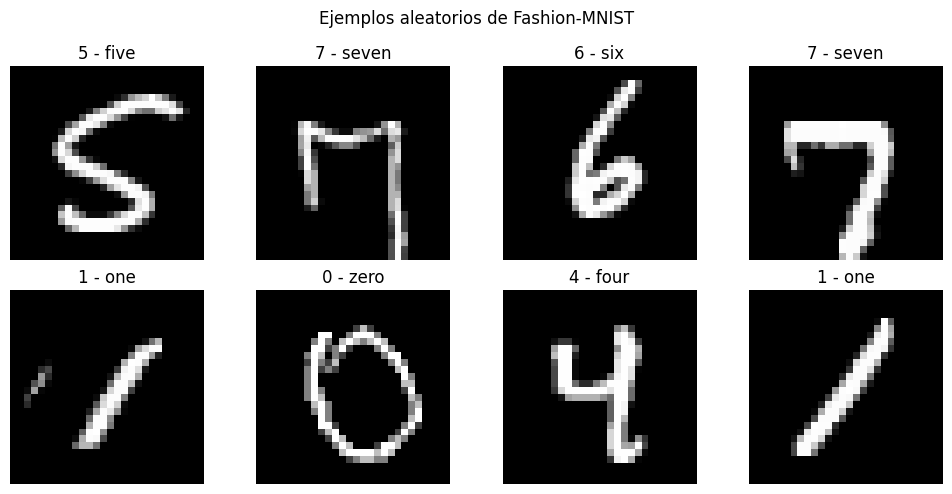

In [ ]:
# Mostrar 8 ejemplos aleatorios
fig, axes = plt.subplots(2, 4, figsize=(10,5))
for ax in axes.flatten():
    idx = np.random.randint(len(train_ds))
    img, label = train_ds[idx]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(classes[label])
    ax.axis('off')
plt.suptitle("Ejemplos aleatorios de Fashion-MNIST")
plt.tight_layout()
plt.show()

Arquitectura sencilla de 3 capas:  
 - Flatten 28×28 → 784  
 - Hidden1: 784 → 128, ReLU  
 - Hidden2: 128 → 64, ReLU  
 - Output: 64 → 10, Softmax

In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

model = MLP().to(device)
print(model)

MLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)


In [ ]:
# - **Loss:** CrossEntropy
# - **Optimizer:** Adam
# - Registramos loss y accuracy en train y validation (usamos parte del train como val)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
# Dividir un 10% de train para validación
val_size = int(0.1 * len(train_ds))
train_size = len(train_ds) - val_size
train_ds, val_ds = torch.utils.data.random_split(train_ds, [train_size, val_size])
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=1000)

n_epochs = 10
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

for epoch in range(1, n_epochs+1):
    # --- TRAIN ---
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)
    train_loss = running_loss / total
    train_acc  = correct / total

    # --- VALIDACIÓN ---
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
    val_loss = val_loss / total
    val_acc  = correct / total

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch}/{n_epochs}  "
          f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f}  "
          f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")

Epoch 1/10  Train loss: 0.5414, acc: 0.8324  Val loss: 0.2554, acc: 0.9203
Epoch 2/10  Train loss: 0.2865, acc: 0.9140  Val loss: 0.1713, acc: 0.9482
Epoch 3/10  Train loss: 0.2313, acc: 0.9308  Val loss: 0.1558, acc: 0.9508
Epoch 4/10  Train loss: 0.2060, acc: 0.9378  Val loss: 0.1324, acc: 0.9587
Epoch 5/10  Train loss: 0.1860, acc: 0.9426  Val loss: 0.1169, acc: 0.9642
Epoch 6/10  Train loss: 0.1755, acc: 0.9475  Val loss: 0.1242, acc: 0.9623
Epoch 7/10  Train loss: 0.1656, acc: 0.9502  Val loss: 0.1112, acc: 0.9640
Epoch 8/10  Train loss: 0.1573, acc: 0.9518  Val loss: 0.1104, acc: 0.9677
Epoch 9/10  Train loss: 0.1492, acc: 0.9547  Val loss: 0.1074, acc: 0.9670
Epoch 10/10  Train loss: 0.1457, acc: 0.9556  Val loss: 0.1140, acc: 0.9653


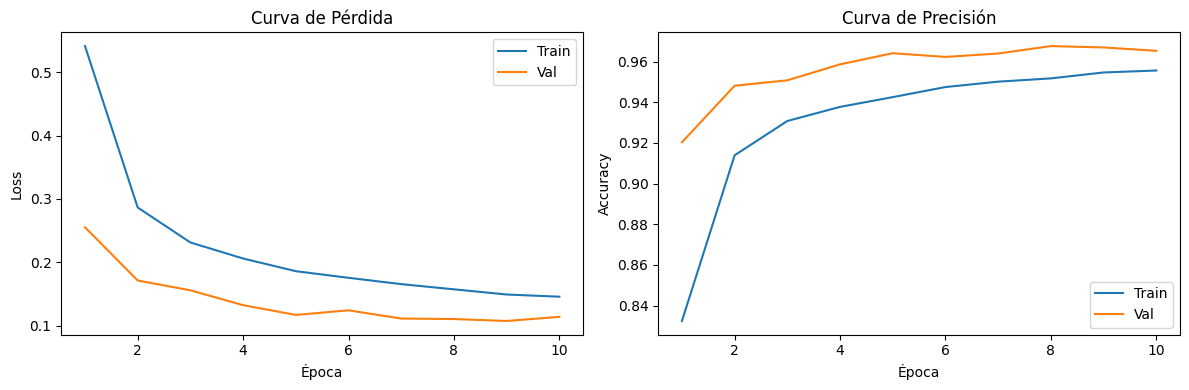

In [ ]:
# Curvas de Loss y Accuracy

epochs = range(1, n_epochs+1)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs, history['train_loss'], label='Train')
plt.plot(epochs, history['val_loss'],   label='Val')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Curva de Pérdida')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, history['train_acc'], label='Train')
plt.plot(epochs, history['val_acc'],   label='Val')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.title('Curva de Precisión')
plt.legend()

plt.tight_layout()
plt.show()

Classification Report:

              precision    recall  f1-score   support

    0 - zero       0.98      0.98      0.98       980
     1 - one       0.97      0.99      0.98      1135
     2 - two       0.96      0.96      0.96      1032
   3 - three       0.97      0.96      0.97      1010
    4 - four       0.96      0.97      0.97       982
    5 - five       0.95      0.97      0.96       892
     6 - six       0.94      0.98      0.96       958
   7 - seven       0.97      0.94      0.95      1028
   8 - eight       0.97      0.96      0.96       974
    9 - nine       0.97      0.94      0.96      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.97      0.96      0.96     10000



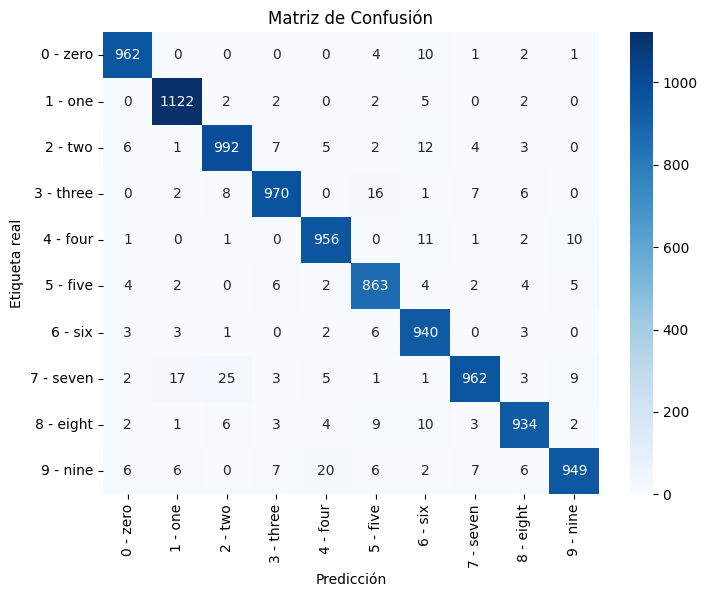

In [ ]:
# Reporte de clasificación
# Matriz de confusión
# Predecir sobre test
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=classes))

# Matriz de confusión
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.title('Matriz de Confusión')
plt.show()

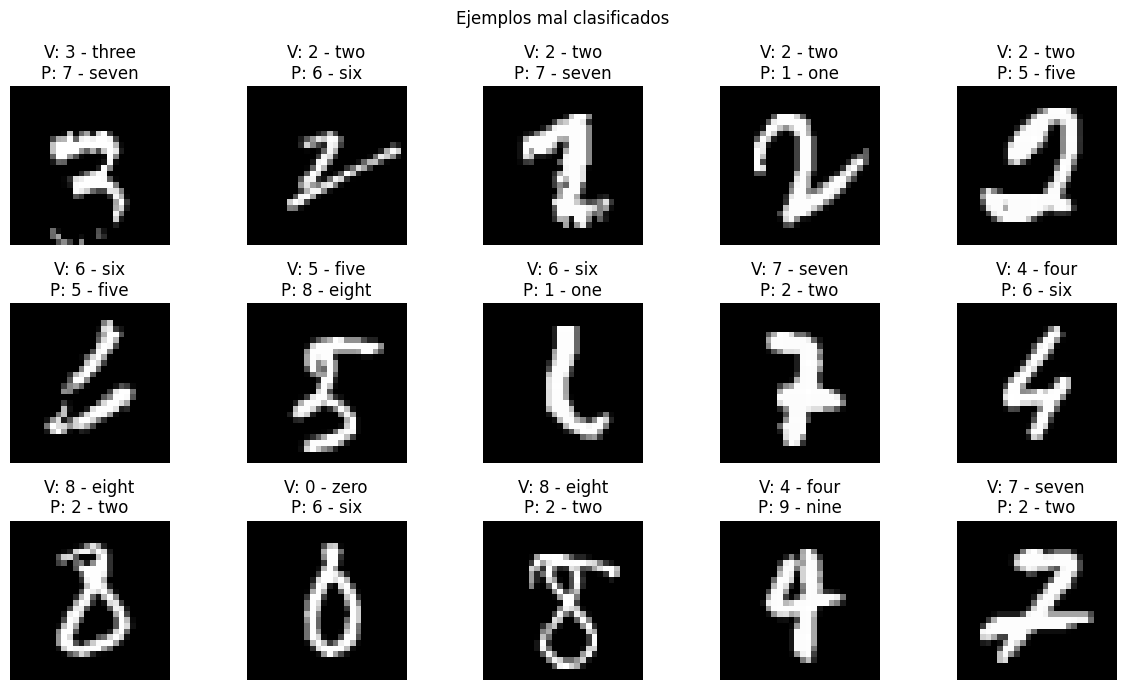

In [ ]:
# Mostramos algunas imágenes que el modelo etiquetó incorrectamente.
mis_idx = [i for i,(p,l) in enumerate(zip(all_preds, all_labels)) if p!=l]
fig, axes = plt.subplots(3, 5, figsize=(12,7))
for ax, idx in zip(axes.flatten(), np.random.choice(mis_idx, 15, replace=False)):
    img, label = test_ds[idx]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"V: {classes[label]}\nP: {classes[all_preds[idx]]}")
    ax.axis('off')
plt.suptitle("Ejemplos mal clasificados")
plt.tight_layout()
plt.show()